# Interpretabilidad completa de una RNN

En este notebook se encuentra el procedimiento completo de la interpretabilidad de una RNN completa. Está todo el código disponible para modificar exclusivamente los hiperparámetros del modelo y el dataset que se quiere utilizar.

In [1]:
import numpy as np
import pandas as pd
import scipy
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, SimpleRNN, Dropout, Reshape
from tensorflow.keras.regularizers import l1_l2
from tensorflow.keras import Model
from sklearn.utils import class_weight
from sklearn.metrics import confusion_matrix

import mne
import matplotlib.colors as mcolors
import seaborn as sns

from graphviz import Digraph

2025-08-27 17:07:24.107672: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-08-27 17:07:24.967090: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


## Funciones auxiliares

In [2]:
def train_test_split(dataset_x_all_users, dataset_y_all_users, user, i, model_name, validation=3):
    if validation < 0 or validation > 3:
      raise Exception("Validation must be 0, 1, 2, or 3")

    if validation == 1:
      train_1 = 2
      train_2 = 3

    elif validation == 2:
      train_1 = 1
      train_2 = 3

    elif validation == 3:
      train_1 = 1
      train_2 = 2

    dataset_x_complete = dataset_x_all_users[user]
    dataset_y_complete = dataset_y_all_users[user]

    X_test = dataset_x_complete[i]
    Y_test = dataset_y_complete[i]

    if validation == 0:
      X_train = np.concatenate((dataset_x_complete[(i+1)%4], dataset_x_complete[(i+2)%4], dataset_x_complete[(i+3)%4]), axis=0)
      Y_train = np.concatenate((dataset_y_complete[(i+1)%4], dataset_y_complete[(i+2)%4], dataset_y_complete[(i+3)%4]))

      return X_train, X_test, Y_train, Y_test

    else:
      X_train = np.concatenate((dataset_x_complete[(i+train_1)%4], dataset_x_complete[(i+train_2)%4]), axis=0)
      Y_train = np.concatenate((dataset_y_complete[(i+train_1)%4], dataset_y_complete[(i+train_2)%4]))

      X_val = dataset_x_complete[(i+validation)%4]
      Y_val = dataset_y_complete[(i+validation)%4]

      return X_train, X_val, X_test, Y_train, Y_val, Y_test

In [3]:
# Funciones auxiliares necesarias para generar el autómata finito con variable acumulativa

def a_donde_llego(estado_ini, tabla_transiciones):
    lista_estados_destino = set()
    for simbolo in tabla_transiciones[estado_ini]:
        lista_estados_destino.add(tabla_transiciones[estado_ini][simbolo])
    return list(lista_estados_destino)

def define_transicion(estado_ini, estado_fin, tabla_transiciones):
    
    if estado_fin not in a_donde_llego(estado_ini, tabla_transiciones):
        return []
    
    simbolos_etiqueta = set()
    for simbolo in tabla_transiciones[estado_ini]:
        if simbolo == -2:
            continue
        if estado_fin == tabla_transiciones[estado_ini][simbolo]:
            simbolos_etiqueta.add(simbolo)
    return list(simbolos_etiqueta)

def crear_diagrama_de_estados(estados, transiciones, aceptacion, estado_inicial, z_values, draw_dollar=True, draw_cabezas=False):
    # Crear un objeto Digraph
    fsm = Digraph(format='png')

    # Configurar orientación hacia la derecha
    fsm.attr(rankdir='LR')

    fsm.node("", shape="none", label="")  # Nodo invisible para la flecha inicial
    fsm.edge("", str(estado_inicial))  # Flecha hacia el estado inicial
    
    # Crear un colormap personalizado de verde (#00FF00) a blanco (#FFFFFF)
    custom_cmap = LinearSegmentedColormap.from_list("custom_green_white", ["#FFFFFF", "#00FF00"])

    # Función para generar el color de cada nodo basado en z(h)
    def get_color(z):
        rgba = custom_cmap(z[0])  # z debe estar entre 0 y 1
        r, g, b, _ = [int(255 * v) for v in rgba]
        return f"#{r:02x}{g:02x}{b:02x}"

    # Añadir los estados (nodos)
    for estado in estados:
        if str(estado) == "-2":
            continue
        # Asignar un color según el valor de z(h)
        color = get_color(z_values.get(estado, 0))  # Si no hay z(h), asigna 0 (vacío)
        fsm.node(str(estado), color="black", fillcolor=color, style="filled", fontcolor="black", shape="ellipse", width="0.6")

    for origen in transiciones:
        if str(origen) == "-2":
            continue
        for destino in a_donde_llego(origen, transiciones):
            simbolos = define_transicion(origen, destino, transiciones)
            simbolos_str = ",".join([str(x) for x in simbolos])
            fsm.edge(str(origen), str(destino), label=simbolos_str)

    print(fsm.source)
    # Renderizar el gráfico
    fsm.render("img/automata_prm", format="png")
    
    # Crear la barra de colores
    fig, ax = plt.subplots(figsize=(0.5, 10))  # Tamaño ajustado para la barra de colores
    gradient = np.linspace(0, 1, 256).reshape(-1, 1)  # Gradiente de 0 a 1
    gradient = np.flip(gradient, axis=0)  # Invertir para que el verde esté abajo
    ax.imshow(gradient, aspect='auto', cmap=custom_cmap)  # Usar el colormap 'Greens'
    
    # Añadir ticks y etiquetas al lado de la barra
    ax.set_xticks([])  # Sin ticks en el eje x
    ax.set_yticks(np.linspace(255, 0, 5))  # Ticks en los extremos
    ax.set_yticklabels(np.linspace(0, 1, 5))  # Etiquetas correspondientes a 0 y 1
    ax.tick_params(axis='y', which='both', length=0)  # Ocultar las líneas de los ticks
    ax.set_title("y(h)", fontsize=12, pad=10)  # Etiqueta de la barra

    # Guardar la barra de colores como imagen
    plt.savefig("img/colorbar.png", bbox_inches='tight', pad_inches=0)

    # Mostrar el grafo y la barra de colores juntos
    return fsm

In [4]:
# Función de tanh redondeada
def round_tanh(decimals=0):
    @tf.custom_gradient
    def _rounded_tanh(x):
        scale = 10**decimals
        z = tf.tanh(x)
        output = tf.math.round(z*scale) / scale

        def backward(dy):
            custom_grad = 1.0 - tf.square(tf.tanh(x))
            return dy * custom_grad

        return output, backward
    return _rounded_tanh

In [5]:
# Función de construcción del modelo

def build_model_interpretability(batch_size, seq_len, input_dim, recurrent_units, optimizer, RNN, 
                                discretizer_units=10,
                                dropout=0.0, recurrent_input_dropout=0.0,
                                output_dropout=0.0, intern_dense_dropout=0.0,
                                l1reg_kernel=0.0, l2reg_kernel=0.0,
                                l1reg_recurrent=0.0, l2reg_recurrent=0.0,
                                l1reg_hidden=0.0, l2reg_hidden=0.0,
                                l1reg_output=0.0, l2reg_output=0.0,
                                l1reg_discretizer=0.0, l2reg_discretizer=0.0):

    input_layer = Input(batch_shape=[batch_size, seq_len, input_dim], name='InputLayer')
    
    discretizer_layer = tf.keras.layers.Dense(discretizer_units, 
                                              activation=round_tanh(),
                                              kernel_regularizer=l1_l2(l1reg_discretizer,l2reg_discretizer))(input_layer)

    rec = RNN(recurrent_units,
              activation=round_tanh(),
              return_sequences=True,
              stateful=False,
              kernel_regularizer=l1_l2(l1reg_kernel, l2reg_kernel),
              recurrent_regularizer=l1_l2(l1reg_recurrent, l2reg_recurrent),
              name='RNN_layer')(discretizer_layer)

    softmax_layer = Dense(1, activation='sigmoid', kernel_regularizer=l1_l2(l1reg_hidden, l2reg_hidden),
                        name='softmax')(rec)

    output_layer = Reshape((-1, seq_len))(softmax_layer) # Consider each timestep output as a different neuron

    output_layer = Dense(1, activation='sigmoid', use_bias = False,
                       kernel_regularizer=l1_l2(l1reg_output, l2reg_output),
                      )(output_layer)
    
    output_layer = Reshape((-1, ))(output_layer)

    model = Model(inputs=input_layer, outputs=output_layer)
    model_x = Model(inputs=input_layer, outputs=discretizer_layer)
    model_rec = Model(inputs=input_layer, outputs=rec)
    model_z = Model(inputs=input_layer, outputs=softmax_layer)
    model_rec_z = Model(inputs=rec, outputs=softmax_layer)
    
    model.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['binary_crossentropy'])

    return model, model_x, model_rec, model_z, model_rec_z

In [6]:
# Función utilizada para pintar las cabezas para la interpretabilidad de los símbolos de entrada

def pinta_cabeza(R, path='./', image_name='noname.png', vmax=None, figname="noname"):
    if vmax is None:
        vmax = np.abs(R).max()
    vmin = -vmax
    
    df = pd.DataFrame(np.concatenate((R[:, None], nombres_electrodos_buenos[:, None]), axis=1), columns=['relevance', 'name'])
    df['relevance'] = df['relevance'].astype(float)
    df = df.sort_values(by='relevance', ascending=False)

    biosemi_montage = mne.channels.make_standard_montage('biosemi32') # Es equivalente a nuestros electrodos
    data_info = mne.create_info(ch_names=df['name'].tolist(), sfreq=250., ch_types='eeg')
    data_evoked = mne.EvokedArray(df['relevance'].to_numpy()[:, None].tolist(), data_info)
    data_evoked.set_montage(biosemi_montage)
    fig, ax = plt.subplots(figsize=(7, 7))
    mne.viz.plot_topomap(data_evoked.data[:, 0], data_evoked.info, show=False,
                         cmap='bwr', vlim=(vmin,vmax),
                         names=df['name'].tolist(), contours=0,
                         mask=np.array([True for i in range(32)]), mask_params=dict(markersize=0),
                         axes=ax)
    # Usa el subplot definido
    if figname is not None:
        plt.title(figname, size=36)
    plt.savefig(path + image_name)
    print(" > Figure saved at " + path + image_name)

## Descarga de datos

Se descargan los datos de Github directamente.

In [7]:
nombres_electrodos_buenos = np.array(['Fp1', 'AF3', 'F7', 'F3', 'FC1', 'FC5', 'T7', 'C3', 'CP1',
                                          'CP5', 'P7', 'P3', 'Pz', 'PO3', 'O1', 'Oz', 'O2', 'PO4',
                                          'P4', 'P8', 'CP6', 'CP2', 'C4', 'T8', 'FC6', 'FC2', 'F4',
                                          'F8', 'AF4', 'Fp2', 'Fz', 'Cz'])

dataset_x_all_users = []
dataset_y_all_users = []
dataset_images_all_users = []
dataset_target_all_users = []

num_trials = 20
path = path = "https://raw.githubusercontent.com/christianolivamoya/tesis-contribuciones-xai-dl/refs/heads/main/dataset/p300/"
indices_electrodos_buenos = np.arange(32, dtype=int)

for user in range(8):
  filenames = ['s'+str(user*4+(i+1))+'.mat' for i in range(4)]
  print("User", user, "filenames:", filenames)

  dataset_x_complete = []
  dataset_y_complete = []
  dataset_images_complete = []
  dataset_target_complete = []

  for filename in filenames:
    print("Loading file", filename)
    try:
        mat = scipy.io.loadmat(filename)
    except:
        !wget $path$filename
        mat = scipy.io.loadmat(filename)

    dataset_x = None
    dataset_y = None
    dataset_images = None
    dataset_target = []

    for i, run in enumerate(mat['runs'][0]):
      data = run[0][0]
      x = data[0][indices_electrodos_buenos][:, :, :num_trials*6]
      y = data[1][0, :num_trials*6]
      images = data[2][0, :num_trials*6]
      target = data[3][0][0]

      if dataset_x is None:
        dataset_x = x
        dataset_y = y
        dataset_images = images
      else:
        dataset_x = np.concatenate((dataset_x, x), axis=-1)
        dataset_y = np.concatenate((dataset_y, y))
        dataset_images = np.concatenate((dataset_images, images))
      dataset_target.append(target)

    dataset_x_complete.append(dataset_x.T)
    dataset_y_complete.append((dataset_y > 0) * 1)
    dataset_images_complete.append(dataset_images)
    dataset_target_complete.append(np.array(dataset_target))

  dataset_x_all_users.append(dataset_x_complete)
  dataset_y_all_users.append(dataset_y_complete)
  dataset_images_all_users.append(dataset_images_complete)
  dataset_target_all_users.append(dataset_target_complete)

User 0 filenames: ['s1.mat', 's2.mat', 's3.mat', 's4.mat']
Loading file s1.mat
Loading file s2.mat
Loading file s3.mat
Loading file s4.mat
User 1 filenames: ['s5.mat', 's6.mat', 's7.mat', 's8.mat']
Loading file s5.mat
Loading file s6.mat
Loading file s7.mat
Loading file s8.mat
User 2 filenames: ['s9.mat', 's10.mat', 's11.mat', 's12.mat']
Loading file s9.mat
Loading file s10.mat
Loading file s11.mat
Loading file s12.mat
User 3 filenames: ['s13.mat', 's14.mat', 's15.mat', 's16.mat']
Loading file s13.mat
Loading file s14.mat
Loading file s15.mat
Loading file s16.mat
User 4 filenames: ['s17.mat', 's18.mat', 's19.mat', 's20.mat']
Loading file s17.mat
Loading file s18.mat
Loading file s19.mat
Loading file s20.mat
User 5 filenames: ['s21.mat', 's22.mat', 's23.mat', 's24.mat']
Loading file s21.mat
Loading file s22.mat
Loading file s23.mat
Loading file s24.mat
User 6 filenames: ['s25.mat', 's26.mat', 's27.mat', 's28.mat']
Loading file s25.mat
Loading file s26.mat
Loading file s27.mat
Loading fi

## Carga de un usuario y sesión

In [8]:
USER = 0
SESSION = 1
X_train, X_test, Y_train, Y_test = train_test_split(dataset_x_all_users, dataset_y_all_users, USER, SESSION, "LSTM", 0)

## Definición de hiperparámetros

In [9]:
import os

batch_size = 16
seq_len = 32
input_dim = 32
recurrent_units = 20
discretizer_units = 8
learning_rate = 1e-3
clipnorm = None # 1.0
clipvalue = None
l1reg_discretizer = 0.015
l1reg_kernel = 0.002
l1reg_recurrent = 0.002
l1reg_hidden = 0.0
l1reg_output = 0.0

class_weights = True

if class_weights:
    class_weights = class_weight.compute_class_weight(class_weight='balanced',
                                                  classes=np.unique(Y_train),
                                                  y=Y_train
                                                 ) if class_weights else None

## Construcción y entrenamiento del modelo

In [10]:
optimizer = tf.keras.optimizers.Nadam(learning_rate, clipnorm=clipnorm, clipvalue=clipvalue)

(model, 
 model_discretizer, 
 model_rec, 
 model_z, 
 model_rec_z) = build_model_interpretability(batch_size, 
                                             seq_len, 
                                             input_dim, 
                                             recurrent_units, 
                                             optimizer, 
                                             tf.keras.layers.SimpleRNN, 
                                             discretizer_units=discretizer_units,
                                             l1reg_kernel=l1reg_kernel, 
                                             l1reg_recurrent=l1reg_recurrent,
                                             l1reg_hidden=l1reg_hidden, 
                                             l1reg_output=l1reg_output,
                                             l1reg_discretizer=l1reg_discretizer)

print(" > Entrenando USUARIO", USER, "- SESION", SESSION, "- L1", l1reg_discretizer)

model.fit(X_train, Y_train, batch_size=batch_size, verbose=1, epochs=50, class_weight=dict(enumerate(class_weights)))

model.save_weights("p300_user"+str(USER)+"_session"+str(SESSION)+"_l1"+str(l1reg_discretizer)+"_MODEL")
model_discretizer.save_weights("p300_user"+str(USER)+"_session"+str(SESSION)+"_l1"+str(l1reg_discretizer)+"_MODEL_DISCRETIZER")
model_rec.save_weights("p300_user"+str(USER)+"_session"+str(SESSION)+"_l1"+str(l1reg_discretizer)+"_MODEL_REC")
model_z.save_weights("p300_user"+str(USER)+"_session"+str(SESSION)+"_l1"+str(l1reg_discretizer)+"_MODEL_Z")
model_rec_z.save_weights("p300_user"+str(USER)+"_session"+str(SESSION)+"_l1"+str(l1reg_discretizer)+"_MODEL_REC_Z")
print(" > DONE")

2025-08-27 17:07:27.486824: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-08-27 17:07:27.518079: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-08-27 17:07:27.518295: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysf

 > Entrenando USUARIO 0 - SESION 1 - L1 0.015
Epoch 1/50


2025-08-27 17:07:29.257203: I tensorflow/compiler/xla/service/service.cc:168] XLA service 0x25fc5f60 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-08-27 17:07:29.257244: I tensorflow/compiler/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA GeForce GTX 970, Compute Capability 5.2
2025-08-27 17:07:29.266577: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:255] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-08-27 17:07:29.279691: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:432] Loaded cuDNN version 8600
2025-08-27 17:07:29.405642: I ./tensorflow/compiler/jit/device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


135/135 [==============================] - 4s 15ms/step - loss: 1.5407 - binary_crossentropy: 0.6250
Epoch 2/50
135/135 [==============================] - 2s 14ms/step - loss: 1.2813 - binary_crossentropy: 0.6859
Epoch 3/50
135/135 [==============================] - 2s 14ms/step - loss: 1.0883 - binary_crossentropy: 0.6957
Epoch 4/50
135/135 [==============================] - 2s 14ms/step - loss: 0.9541 - binary_crossentropy: 0.6844
Epoch 5/50
135/135 [==============================] - 2s 14ms/step - loss: 0.8584 - binary_crossentropy: 0.6795
Epoch 6/50
135/135 [==============================] - 2s 14ms/step - loss: 0.8136 - binary_crossentropy: 0.6917
Epoch 7/50
135/135 [==============================] - 2s 13ms/step - loss: 0.7894 - binary_crossentropy: 0.6780
Epoch 8/50
135/135 [==============================] - 2s 13ms/step - loss: 0.7673 - binary_crossentropy: 0.6731
Epoch 9/50
135/135 [==============================] - 2s 13ms/step - loss: 0.7534 - binary_crossentropy: 0.6819
Epo

## Evaluación del modelo

In [11]:
(model, 
 model_discretizer, 
 model_rec, 
 model_z, 
 model_rec_z) = build_model_interpretability(batch_size, 
                                             seq_len, 
                                             input_dim, 
                                             recurrent_units, 
                                             "SGD", 
                                             tf.keras.layers.SimpleRNN, 
                                             discretizer_units=discretizer_units)
        
model.load_weights("p300_user"+str(USER)+"_session"+str(SESSION)+"_l1"+str(l1reg_discretizer)+"_MODEL")
model_discretizer.load_weights("p300_user"+str(USER)+"_session"+str(SESSION)+"_l1"+str(l1reg_discretizer)+"_MODEL_DISCRETIZER")
model_rec.load_weights("p300_user"+str(USER)+"_session"+str(SESSION)+"_l1"+str(l1reg_discretizer)+"_MODEL_REC")
model_z.load_weights("p300_user"+str(USER)+"_session"+str(SESSION)+"_l1"+str(l1reg_discretizer)+"_MODEL_Z")
model_rec_z.load_weights("p300_user"+str(USER)+"_session"+str(SESSION)+"_l1"+str(l1reg_discretizer)+"_MODEL_REC_Z")

# NUM ESTADOS
hs = model_rec.predict(X_train, verbose=0)
hs_all = np.concatenate(hs)
print(" > NUM ESTADOS:", np.unique(hs_all, axis=0).shape[0])

# NUM SIMBOLOS
xs = model_discretizer.predict(X_train, verbose=0)
xs_all = np.concatenate(xs)
print(" > NUM SIMBOLOS:", np.unique(xs_all, axis=0).shape[0])

# BAC val.
preds = model.predict(X_test, verbose=0, batch_size=batch_size)
tn, fp, fn, tp = confusion_matrix(Y_test, preds[:, -1] > 0.5).ravel()
tpr = tp / (tp + fn)
tnr = tn / (tn + fp)
balanced_accuracy_test = (tpr + tnr) / 2
print(" > BAC:", balanced_accuracy_test)

 > NUM ESTADOS: 6
 > NUM SIMBOLOS: 3
 > BAC: 0.6725


## Análisis del modelo

### Capa discretizadora

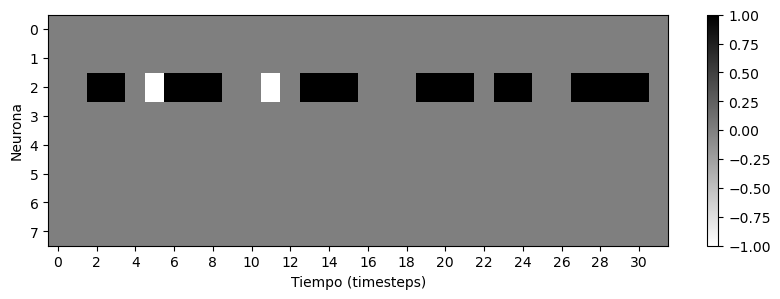

In [12]:
# Visualización de la activación de la capa discretizadora
plt.figure(figsize=(10, 3))
plt.imshow(xs[0].T, cmap="binary", aspect="auto")
plt.colorbar()
plt.xlabel("Tiempo (timesteps)")
plt.ylabel("Neurona")
plt.xticks(range(0, 32, 2), range(0, 32, 2))
plt.show()

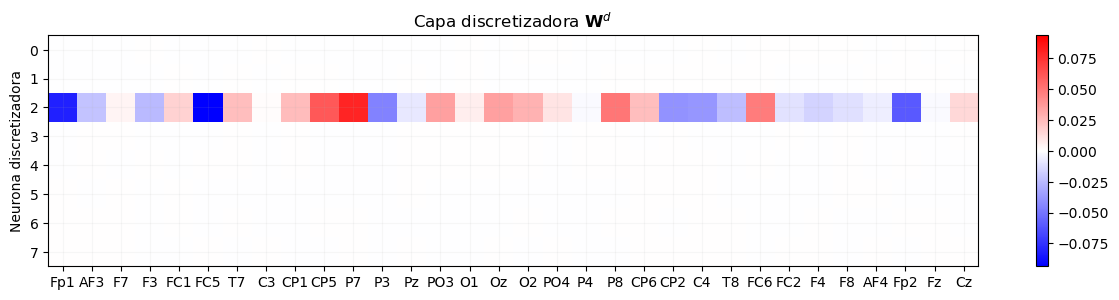

In [13]:
# Visualización de los pesos de la capa discretizadora
Wd = model.layers[1].weights[0].numpy()
vmax = np.abs(Wd).max()
vmin = -vmax
plt.figure(figsize=(15, 3))
plt.imshow(Wd.T, vmin=vmin, vmax=vmax, cmap="bwr", aspect="auto")
plt.xticks(range(32), nombres_electrodos_buenos)
plt.ylabel("Neurona discretizadora")
plt.title("Capa discretizadora $\mathbf{W}^d$")
plt.grid(alpha=0.1)
plt.colorbar()
plt.show()

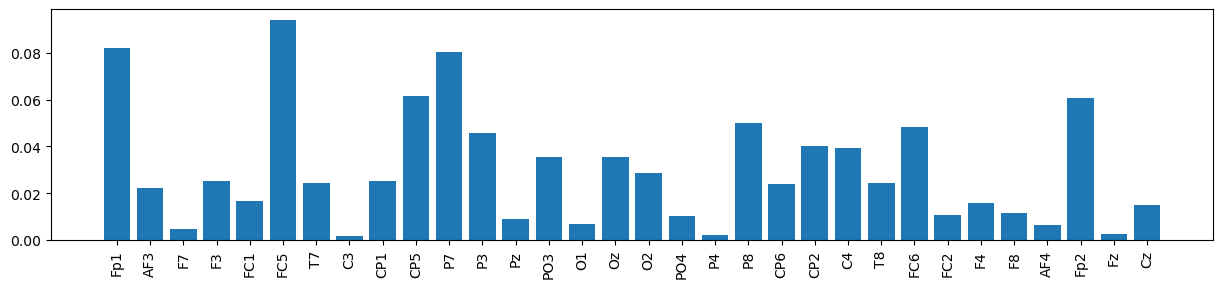

In [14]:
# Relevancia de la capa discretizadora
R = np.abs(Wd).sum(axis=1)

plt.figure(figsize=(15,3))
plt.bar(range(32),R)
plt.xticks(range(32), nombres_electrodos_buenos, rotation="vertical")
plt.show()

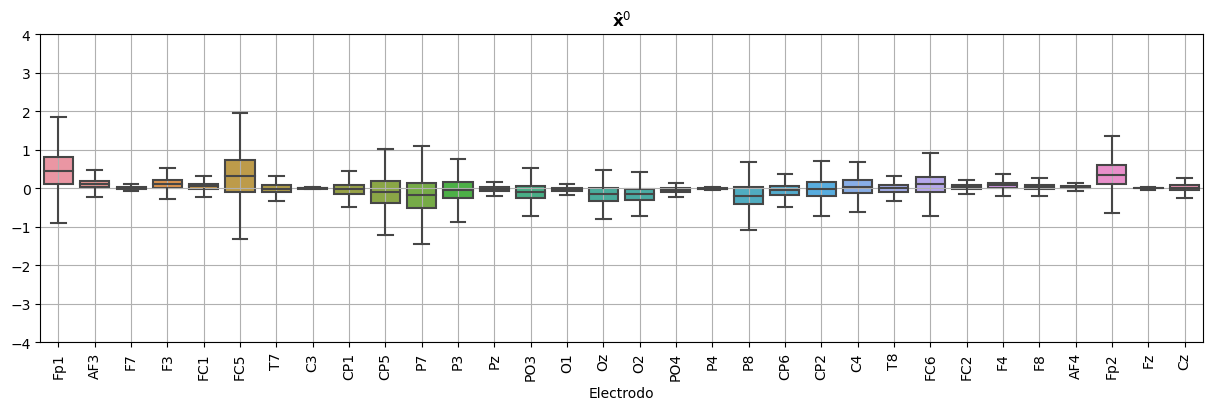

 > Figure saved at ./cabeza_simbolo_0.png


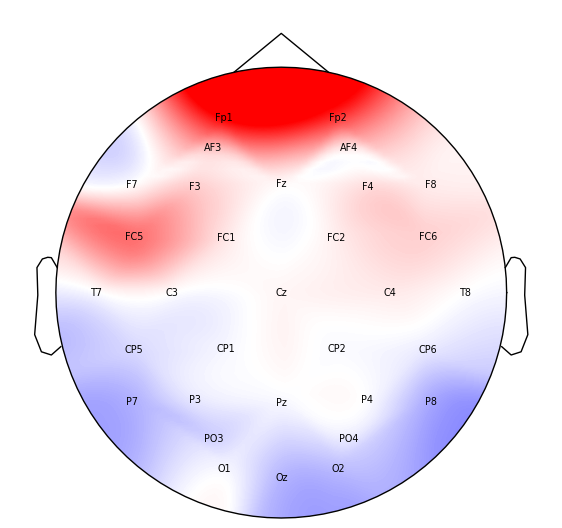

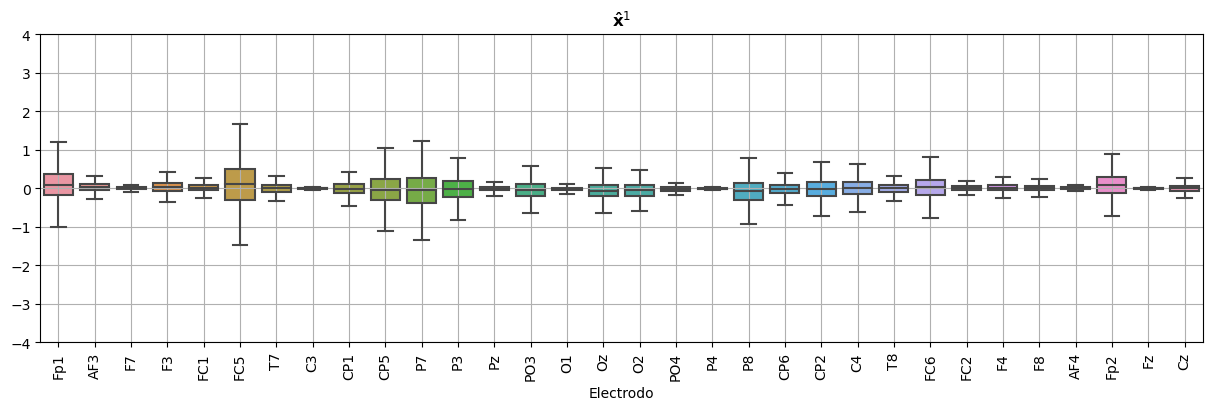

 > Figure saved at ./cabeza_simbolo_1.png


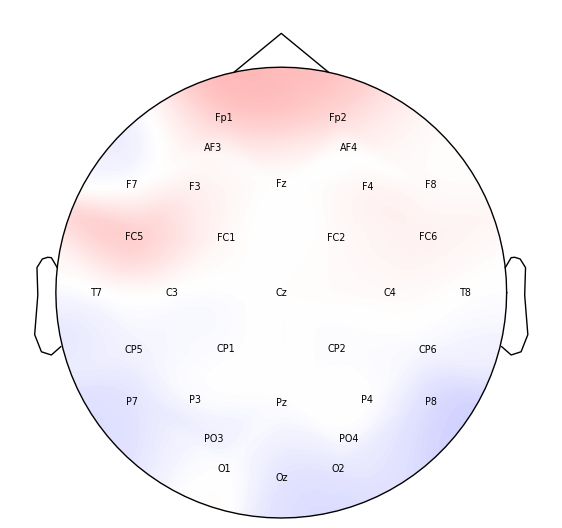

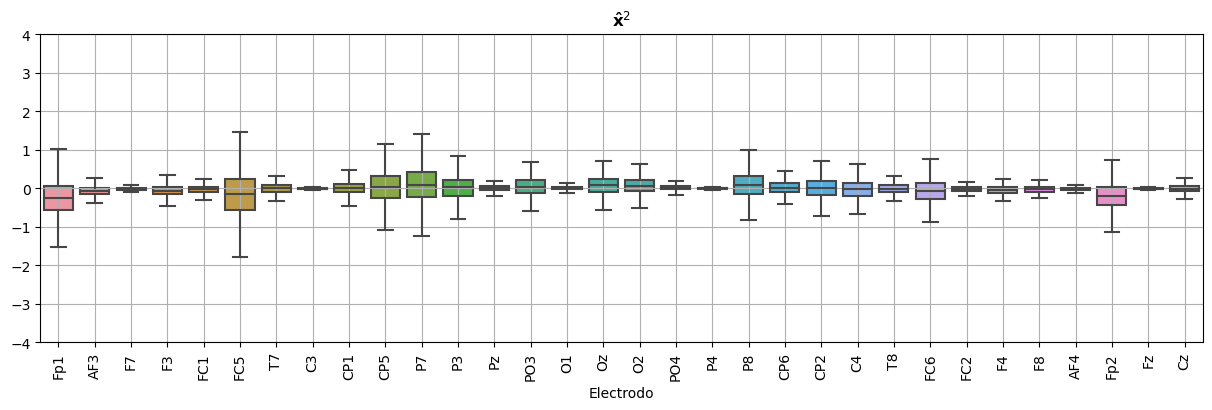

 > Figure saved at ./cabeza_simbolo_2.png


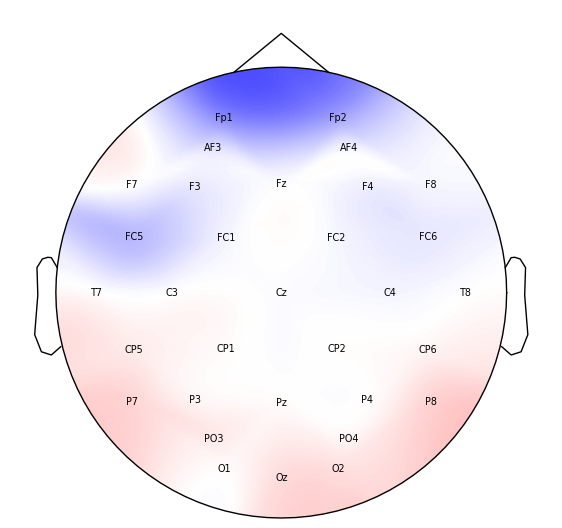

In [15]:
# Representación de los símbolos discretos de la capa discretizadora
x2id = {}
id2x = {}
for i, x in enumerate(np.unique(xs_all, axis=0).astype(int)):
    x2id[tuple(x)] = i
    id2x[i] = tuple(x)
    
xs_token = []
for x in xs:
    x_token = []
    for xt in x:
        token = tuple(xt.astype(int))
        x_token.append(x2id[token])
    xs_token.append(x_token)
xs_token = np.array(xs_token)
xs_token.shape

vmax = []
for token in np.unique(xs_token):
    vmax.append(np.abs((X_train[xs_token == token]*np.abs(R)).mean(axis=0)).max())
vmax = np.max(vmax)
for token in np.unique(xs_token):
    plt.figure(figsize=(15, 4))
    sns.boxplot(data=X_train[xs_token == token]*np.abs(R), showfliers=False)
    plt.xticks(range(32), nombres_electrodos_buenos, rotation=90)
    plt.title("$\mathbf{\hat{x}}^"+str(token)+"$")
    plt.ylim(-4, 4)
    plt.grid()
    plt.xlabel("Electrodo")
    plt.show()
    pinta_cabeza((X_train[xs_token == token]*np.abs(R)).mean(axis=0), vmax=vmax, 
                 #figname="Símbolo discreto $\mathbf{x}^{"+str(token)+"}$",
                 path="./",
                 image_name=f"cabeza_simbolo_{token}.png",
                 figname=None)

### Capa recurrente

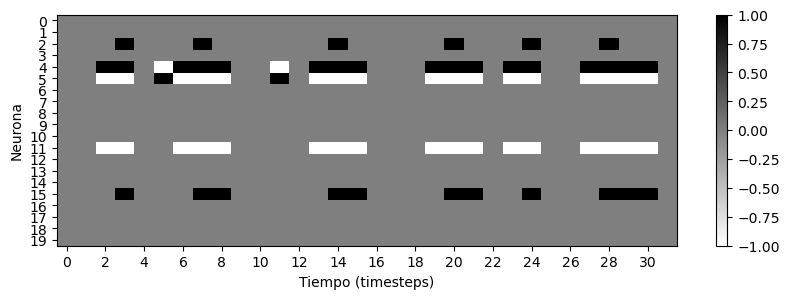

In [16]:
# Visualización de la activación de la capa recurrente
plt.figure(figsize=(10, 3))
plt.imshow(hs[0].T, cmap="binary", aspect="auto")
plt.colorbar()
plt.xlabel("Tiempo (timesteps)")
plt.ylabel("Neurona")
plt.yticks(range(20), range(20))
plt.xticks(range(0, 32, 2), range(0, 32, 2))
plt.show()

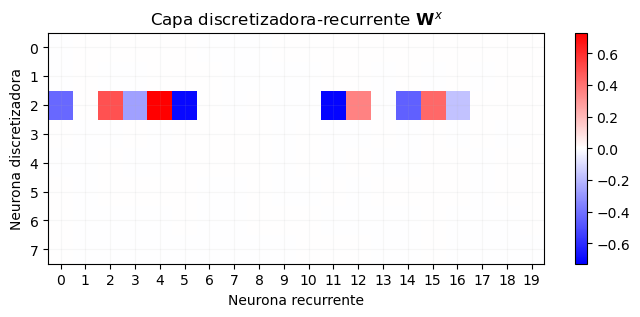

In [17]:
# Pesos de la capa entrada-recurrente

Wxh = model.layers[2].weights[0].numpy()
vmax = np.abs(Wxh).max()
vmin = -vmax
plt.figure(figsize=(8, 3))
plt.imshow(Wxh, vmin=vmin, vmax=vmax, cmap="bwr", aspect="auto")
plt.ylabel("Neurona discretizadora")
plt.xlabel("Neurona recurrente")
plt.title("Capa discretizadora-recurrente $\mathbf{W}^x$")
plt.xticks(range(20), range(20))
plt.grid(alpha=0.1)
plt.colorbar()
plt.show()

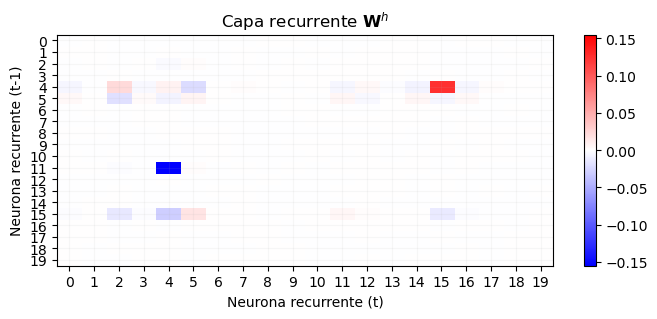

In [18]:
# Pesos de la capa recurrente-recurrente

Whh = model.layers[2].weights[1].numpy()
vmax = np.abs(Whh).max()
vmin = -vmax
plt.figure(figsize=(8, 3))
plt.imshow(Whh, vmin=vmin, vmax=vmax, cmap="bwr", aspect="auto")
plt.ylabel("Neurona recurrente (t-1)")
plt.xlabel("Neurona recurrente (t)")
plt.title("Capa recurrente $\mathbf{W}^h$")
plt.xticks(range(20), range(20))
plt.yticks(range(20), range(20))
plt.grid(alpha=0.1)
plt.colorbar()
plt.show()

### Tabla de transiciones del autómata

In [19]:
zs = model_z.predict(X_train)
zs_all = np.concatenate(zs)
zs_all.shape

68/68 [==============================] - 0s 4ms/step


(69120, 1)

In [20]:
h2id = {}
id2h = {}

h2id[tuple([0]*20)] = -1
id2h[-1] = tuple([0]*20)

c = 0
for i, h in enumerate(np.unique(hs_all, axis=0).astype(int)):
    if tuple(h) not in h2id:
        h2id[tuple(h)] = c
        id2h[c] = tuple(h)
        c += 1
        
hs_token = []
h2z = {}
for h, z in zip(hs, zs):
    h_token = []
    for ht, zt in zip(h, z):
        token = tuple(ht.astype(int))
        h_token.append(h2id[token])
        if token not in h2z:
            h2z[h2id[token]] = zt
        else:
            if h2z[h2id[token]] != zt:
                print(" ALGO VA MAL")
    hs_token.append(h_token)
hs_token = np.array(hs_token)
hs_token.shape

from tqdm import tqdm
tabla_transiciones = {}
for i in tqdm(range(len(hs_token))):
    for t in range(32):
        simbolo = xs_token[i, t]
        if t == 0:
            estado_ini = -1
        else:
            estado_ini = hs_token[i, t-1]
            
        estado_fin = hs_token[i, t]
        
        if estado_ini in tabla_transiciones:
            if simbolo in tabla_transiciones[estado_ini]:
                if estado_fin != tabla_transiciones[estado_ini][simbolo]:
                    print(" > ALGO VA MAL")
                    print("    tiempo:", t)
                    print("       ini:", estado_ini)
                    print("   simbolo:", simbolo)
                    print("       fin:", estado_fin)
                    print("     trans:", tabla_transiciones[estado_ini][simbolo])
                else:
                    tabla_transiciones[estado_ini][simbolo] = estado_fin
            else:
                tabla_transiciones[estado_ini][simbolo] = estado_fin
        else:
            tabla_transiciones[estado_ini] = {simbolo: estado_fin}

100%|████████████████████████████████████| 2160/2160 [00:00<00:00, 29060.12it/s]


In [21]:
num_simbolos = np.unique(xs_all, axis=0).shape[0]
num_estados = np.unique(hs_all, axis=0).shape[0]
tabla_transiciones_matriz = np.zeros((num_estados, num_simbolos))
for estado in tabla_transiciones:
    for simbolo in tabla_transiciones[estado]:
        tabla_transiciones_matriz[estado, simbolo] = 1

In [22]:
Wxh = model.layers[2].weights[0].numpy()
Whh = model.layers[2].weights[1].numpy()
bh = model.layers[2].weights[2].numpy()

In [23]:
bd = model.layers[1].weights[1].numpy()
u1 = np.arctanh(-0.5) - bd
u2 = np.arctanh(0.5) - bd

In [24]:
h2id = {}
id2h = {}

h2id[tuple([0]*20)] = -1
id2h[-1] = tuple([0]*20)

c = 0
for i, h in enumerate(np.unique(hs_all, axis=0).astype(int)):
    if tuple(h) not in h2id:
        h2id[tuple(h)] = c
        id2h[c] = tuple(h)
        c += 1

In [25]:
hs_token = []
h2z = {}
for h, z in zip(hs, zs):
    h_token = []
    for ht, zt in zip(h, z):
        token = tuple(ht.astype(int))
        h_token.append(h2id[token])
        if token not in h2z:
            h2z[h2id[token]] = zt
        else:
            if h2z[h2id[token]] != zt:
                print(" ALGO VA MAL")
    hs_token.append(h_token)
hs_token = np.array(hs_token)
hs_token.shape

(2160, 32)

In [26]:
from tqdm import tqdm
tabla_transiciones = {}
for i in tqdm(range(len(hs_token))):
    for t in range(32):
        simbolo = xs_token[i, t]
        if t == 0:
            estado_ini = -1
        else:
            estado_ini = hs_token[i, t-1]
            
        estado_fin = hs_token[i, t]
        
        if estado_ini in tabla_transiciones:
            if simbolo in tabla_transiciones[estado_ini]:
                if estado_fin != tabla_transiciones[estado_ini][simbolo]:
                    print(" > ALGO VA MAL")
                    print("    tiempo:", t)
                    print("       ini:", estado_ini)
                    print("   simbolo:", simbolo)
                    print("       fin:", estado_fin)
                    print("     trans:", tabla_transiciones[estado_ini][simbolo])
                else:
                    tabla_transiciones[estado_ini][simbolo] = estado_fin
            else:
                tabla_transiciones[estado_ini][simbolo] = estado_fin
        else:
            tabla_transiciones[estado_ini] = {simbolo: estado_fin}

100%|████████████████████████████████████| 2160/2160 [00:00<00:00, 28333.42it/s]


In [27]:
num_estados_now = 0
num_estados_prev = len(tabla_transiciones)
while num_estados_prev != num_estados_now:
    print(num_estados_prev, num_estados_now)
    num_estados_prev = len(tabla_transiciones)
    
    transiciones_para_add = []
    for estado in tqdm(tabla_transiciones):
        if len(tabla_transiciones[estado]) == num_simbolos:
            continue
        for simbolo in range(num_simbolos):
            if estado not in tabla_transiciones:
                print(" > SE VA A AÑADIR UN NUEVO ESTADO")
                # Esto no pasa asi que todavia no arreglo el codigo
                pass
            else:
                if simbolo not in tabla_transiciones[estado]:
                    token = np.array(id2x[simbolo], dtype=np.float32)
                    hprev = np.array(id2h[estado], dtype=np.float32)
                    h = tuple(round_tanh()(token @ Wxh + hprev @ Whh + bh).numpy().astype(int))
                    if h in h2id:
                        tabla_transiciones[estado][simbolo] = h2id[h]
                    else:
                        c = max(list(h2id.values()))
                        c += 1
                        h2id[h] = c
                        id2h[c] = h
                        transiciones_para_add.append((estado, simbolo, c))
                else:
                    pass
                
    for estado, simbolo, c in transiciones_para_add:
        tabla_transiciones[estado][simbolo] = c
        tabla_transiciones[c] = {}
                
    num_estados_now = len(tabla_transiciones)

6 0


100%|█████████████████████████████████████████| 6/6 [00:00<00:00, 110376.42it/s]


In [28]:
from matplotlib.colors import LinearSegmentedColormap
# Define los colores y sus posiciones (valores entre 0 y 1)
colors = [
    (0.0, "#8800FF"),    # Azul en el inicio
    (0.5, "white"),   # Blanco en el medio
    (1.0, "#008800"),     # Rojo al final
]

# Crear el colormap
custom_cmap = LinearSegmentedColormap.from_list("mi_colormap", colors)

digraph {
	rankdir=LR
	"" [label="" shape=none]
	"" -> -1
	-1 [color=black fillcolor="#85ff85" fontcolor=black shape=ellipse style=filled width=0.6]
	0 [color=black fillcolor="#e0ffe0" fontcolor=black shape=ellipse style=filled width=0.6]
	1 [color=black fillcolor="#b9ffb9" fontcolor=black shape=ellipse style=filled width=0.6]
	2 [color=black fillcolor="#14ff14" fontcolor=black shape=ellipse style=filled width=0.6]
	3 [color=black fillcolor="#08ff08" fontcolor=black shape=ellipse style=filled width=0.6]
	4 [color=black fillcolor="#04ff04" fontcolor=black shape=ellipse style=filled width=0.6]
	-1 -> 0 [label=0]
	-1 -> 2 [label=2]
	-1 -> -1 [label=1]
	2 -> 4 [label=2]
	2 -> -1 [label="0,1"]
	4 -> 1 [label=0]
	4 -> 3 [label=2]
	4 -> -1 [label=1]
	0 -> 0 [label=0]
	0 -> 2 [label=2]
	0 -> -1 [label=1]
	3 -> 1 [label=0]
	3 -> 3 [label=2]
	3 -> -1 [label=1]
	1 -> 0 [label=0]
	1 -> 2 [label=2]
	1 -> -1 [label=1]
}



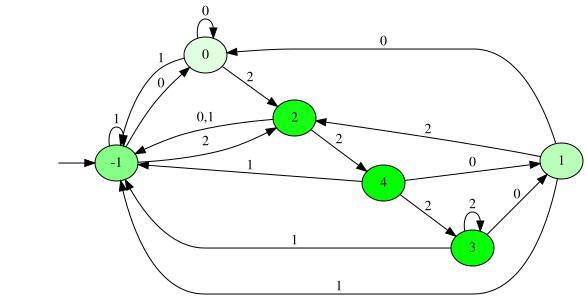

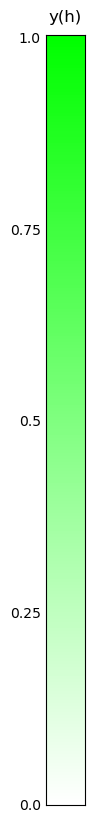

In [29]:
# El autómata generado tiene los símbolos enumerados
crear_diagrama_de_estados(list(id2h.keys()), tabla_transiciones, np.zeros(len(id2h), dtype=int), -1, h2z)

### Pesos de la capa PRM

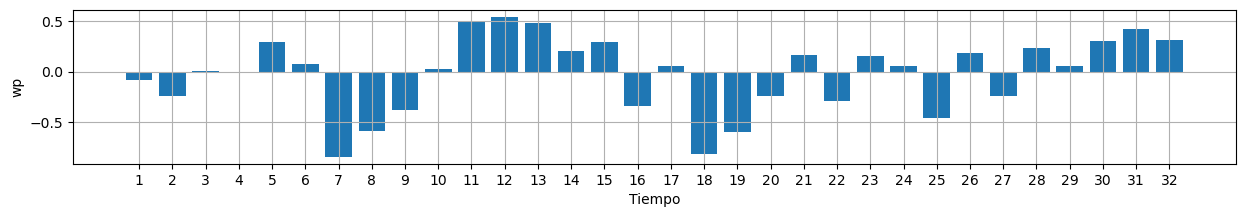

In [30]:
plt.figure(figsize=(15, 2))
plt.bar(range(32), model.layers[-2].weights[0].numpy()[:, 0])
plt.grid()
plt.xticks(range(32), range(1, 33))
plt.xlabel("Tiempo")
plt.ylabel("wp")
plt.show()

### Evaluación de una cadena particular

In [31]:
item = 2145
z_values = (zs[item][:, 0]*model.layers[-2].weights[0].numpy()[:, 0]).cumsum()
h_values = hs_token[item]
x_values = xs_token[item]

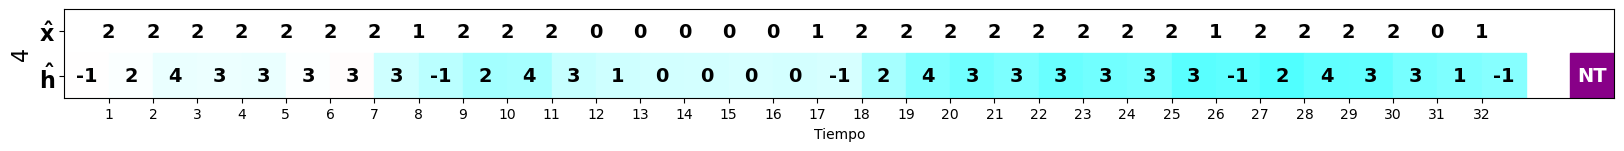

In [32]:
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import matplotlib.image as mpimg

def get_z_scaled(z, minimum=-4, maximum=4):
    z_clipped = np.clip(z, minimum, maximum)
    return (z_clipped+maximum)/(maximum-minimum)

custom_cmap = LinearSegmentedColormap.from_list("custom_blue_white_red", ["#00FFFF", "#FFFFFF", "#FF0000"])


fig, ax = plt.subplots(figsize=(20, 2))  # Más alto para dos filas

# -----------------------------
# Fila superior: x_values
# -----------------------------
for t, (simbolo, z) in enumerate(zip(x_values, z_values)):
    z_scaled = get_z_scaled(z)
    rgba = custom_cmap(z_scaled)
    r, g, b, _ = [int(255 * v) for v in rgba]
    color = f"#{r:02x}{g:02x}{b:02x}"
    
    rectangle = mpatches.Rectangle((t+1, 1), 1, 1, color="#FFFFFF")  # Y=1 para fila superior
    ax.add_artist(rectangle)
    rx, ry = rectangle.get_xy()
    cx = rx
    cy = ry + 0.5

    # Carga imagen correspondiente
    image_path = f"resize_cabeza_simbolo_{simbolo}.png"  # Asegúrate que este nombre concuerda con tus archivos
    try:
        image = mpimg.imread(image_path)
        imagebox = OffsetImage(image, zoom=0.5)  # ajusta el zoom según tamaño imagen
        ab = AnnotationBbox(imagebox, (cx, cy), frameon=False)
        ax.add_artist(ab)
    except FileNotFoundError:
        # Si no encuentra la imagen, puede dejar un texto de fallback
        ax.annotate(str(simbolo), (cx, cy), color='k', weight='bold',
                    fontsize=14, ha='center', va='center')

# -----------------------------
# Fila inferior: h_values
# -----------------------------
rectangle = mpatches.Rectangle((0, 0), 1, 1, color=custom_cmap(get_z_scaled(0.0)))
ax.add_artist(rectangle)
cx = 0.5
cy = 0.5
ax.annotate("-1", (cx, cy), color='k', weight='bold',
            fontsize=14, ha='center', va='center')

for t, (simbolo, z) in enumerate(zip(h_values, z_values)):
    z_scaled = get_z_scaled(z)
    rgba = custom_cmap(z_scaled)
    r, g, b, _ = [int(255 * v) for v in rgba]
    color = f"#{r:02x}{g:02x}{b:02x}"
    
    rectangle = mpatches.Rectangle((t+1, 0), 1, 1, color=color)  # Y=0 para fila inferior
    ax.add_artist(rectangle)
    cx = t + 1.5
    cy = 0.5

    ax.annotate(simbolo, (cx, cy), color='k', weight='bold',
                fontsize=14, ha='center', va='center')

rectangle = mpatches.Rectangle((t+3, 0), 1, 1, color="#FFEE00" if Y_train[item] else "#880088")
ax.add_artist(rectangle)
cx = t + 3.5
cy = 0.5

ax.annotate("T" if Y_train[item] else "NT", (cx, cy),
            color='black' if Y_train[item] else "white", weight='bold',
            fontsize=14, ha='center', va='center')

# Ajustes de ejes
ax.set_aspect('equal')
ax.set_xlim((0, t + 4))
ax.set_ylim((0, 2))  # Ahora hay dos filas
ax.set_xticks(range(1, 33))
ax.set_yticks([0.5, 1.5])
ax.set_yticklabels(["$\mathbf{\hat{h}}$", "$\mathbf{\hat{x}}$"])
ax.tick_params(axis='y', labelsize=16)
#ax.tick_params(axis='x', bottom=False, labelbottom=False)  # Oculta etiquetas X
plt.xlabel("Tiempo")
plt.ylabel("4", size=16)

plt.show()


### Evaluación de la probabilidad a posteriori

In [33]:
pred = model.predict(X_train)
pred.shape

68/68 [==============================] - 0s 4ms/step


(2160, 1)

In [34]:
n_estados = np.unique(hs_all, axis=0).shape[0]
n_estados

6

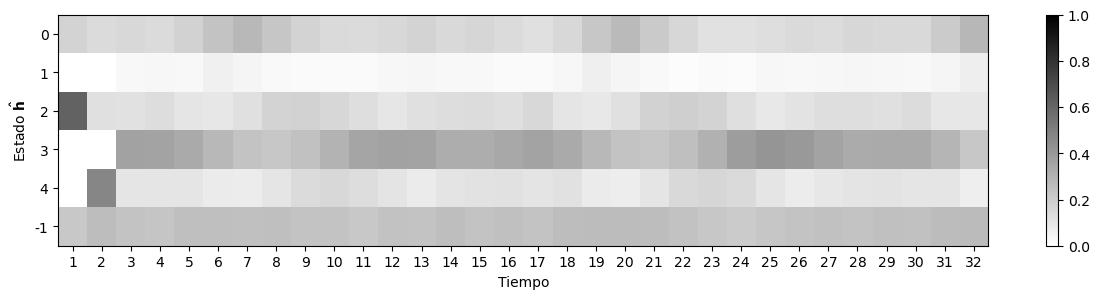

In [35]:
count_token_time = np.zeros((32, len(tabla_transiciones)), dtype=int)
for h in hs_token[Y_train == 0]:
    for t in range(32):
        count_token_time[t][h[t]] += 1
                
count_token_time_NT = count_token_time / (Y_train == 0).sum()

plt.figure(figsize=(15, 3))
plt.imshow(count_token_time_NT.T, cmap="binary", vmin=0, vmax=1, aspect="auto")
plt.yticks(range(len(tabla_transiciones)), list(range(n_estados-1)) + [-1])
plt.xticks(range(32), range(1, 33))
plt.xlabel("Tiempo")
plt.ylabel("Estado $\mathbf{\hat{h}}$")
plt.colorbar()
plt.show()

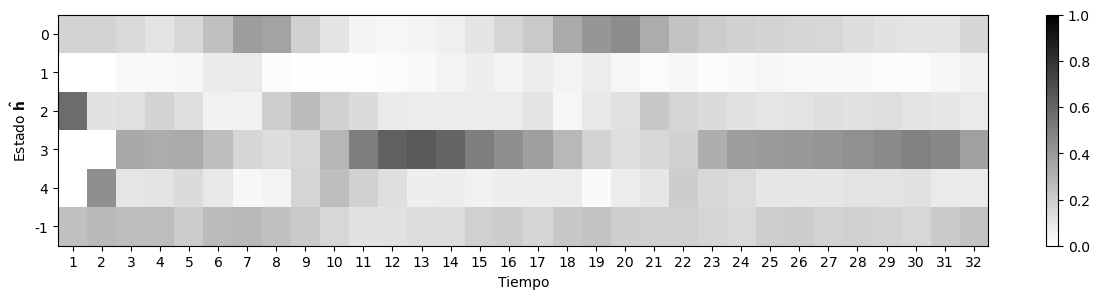

In [36]:
count_token_time = np.zeros((32, len(tabla_transiciones)), dtype=int)
for h in hs_token[Y_train == 1]:
    for t in range(32):
        count_token_time[t][h[t]] += 1
                
count_token_time_T = count_token_time / (Y_train == 1).sum()

plt.figure(figsize=(15, 3))
plt.imshow(count_token_time_T.T, cmap="binary", vmin=0, vmax=1, aspect="auto")
plt.yticks(range(len(tabla_transiciones)), list(range(n_estados-1)) + [-1])
plt.xticks(range(32), range(1, 33))
plt.xlabel("Tiempo")
plt.ylabel("Estado $\mathbf{\hat{h}}$")
plt.colorbar()
plt.show()

In [37]:
prob_NT_condicionado = ((5*count_token_time_NT + 1e-16) / (5*count_token_time_NT + count_token_time_T + 2e-16))
prob_T_condicionado = (count_token_time_T + 1e-16) / (5*count_token_time_NT + count_token_time_T + 2e-16)

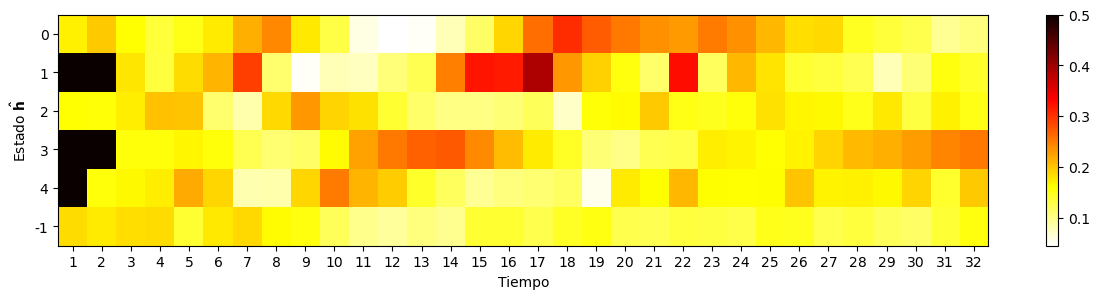

In [38]:
plt.figure(figsize=(15, 3))
plt.imshow(prob_T_condicionado.T, cmap="hot_r", aspect="auto")
plt.yticks(range(len(tabla_transiciones)), list(range(n_estados-1)) + [-1])
plt.xticks(range(32), range(1, 33))
plt.xlabel("Tiempo")
plt.ylabel("Estado $\mathbf{\hat{h}}$")
plt.colorbar()
plt.show()